# FinTrust Banking Analytics
## Week 3 — Advanced Python Analysis

### Objective
To extend the Week 2 exploratory data analysis through deeper comparative analysis, trend analysis, customer segmentation, and validation of key business findings.

### Week 3 Analysis Areas
1. Channel Performance Comparison
2. Daily-Normalized Transaction Trend
3. High-Value Transaction Analysis
4. Customer Segment Behaviour Comparison
5. International vs Domestic Transaction Analysis

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
customers = pd.read_csv("../data/raw/FinTrust_Customer_Data.csv")

transactions = pd.read_csv(
    "../data/processed/FinTrust_Transaction_Data_Cleaned.csv"
)

print("Customer dataset shape:", customers.shape)
print("Transaction dataset shape:", transactions.shape)

Customer dataset shape: (1500, 12)
Transaction dataset shape: (12000, 11)


### Analysis 1 — Channel Performance Comparison

This analysis compares transaction channels based on transaction volume, total transaction value, average transaction value, and success rate to evaluate channel usage and performance.

In [28]:
channel_analysis = transactions.groupby("Channel").agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value_NGN=("Amount_NGN", "sum"),
    Average_Value_NGN=("Amount_NGN", "mean")
).reset_index()

success = (
    transactions.assign(
        Successful=transactions["Transaction_Status"].eq("Successful").astype(int)
    )
    .groupby("Channel")["Successful"]
    .mean()
    .mul(100)
    .reset_index(name="Success_Rate")
)

channel_analysis = channel_analysis.merge(success, on="Channel")

channel_analysis["Total_Value_NGN"] = channel_analysis["Total_Value_NGN"].round(2)
channel_analysis["Average_Value_NGN"] = channel_analysis["Average_Value_NGN"].round(2)
channel_analysis["Success_Rate"] = channel_analysis["Success_Rate"].round(2)

channel_analysis = channel_analysis.sort_values(
    "Total_Transactions", ascending=False
)

channel_analysis

,Channel,Total_Transactions,Total_Value_NGN,Average_Value_NGN,Success_Rate
1,Mobile App,5102,2.401044e+08,47060.83,89.75
2,POS,2393,1.043467e+08,43604.96,90.85
4,Web,1869,8.932500e+07,47792.94,90.85
0,ATM,1747,8.394235e+07,48049.43,91.70
3,USSD,889,4.275895e+07,48097.81,90.33


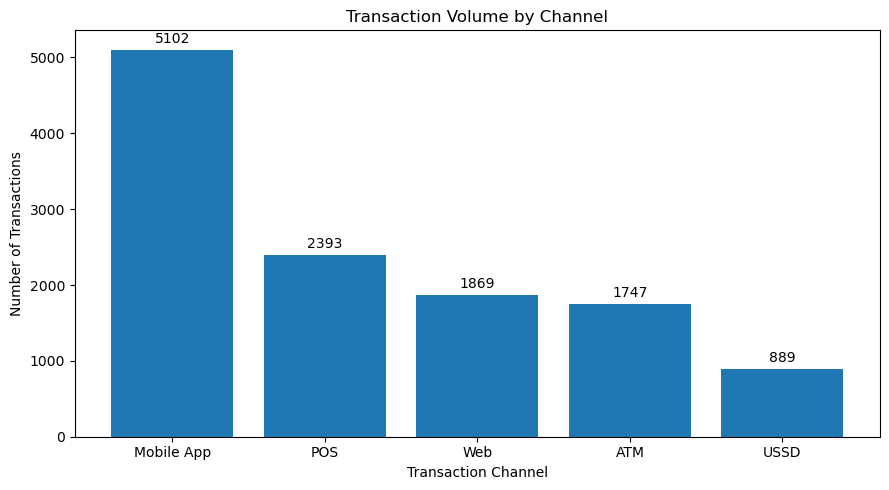

In [29]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    channel_analysis["Channel"],
    channel_analysis["Total_Transactions"]
)

plt.title("Transaction Volume by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")

plt.bar_label(
    bars,
    labels=channel_analysis["Total_Transactions"],
    padding=3
)

plt.tight_layout()
plt.show()

#### Interpretation

The Mobile App was the most frequently used transaction channel, processing 5,102 transactions, followed by POS with 2,393 transactions. It also generated the highest total transaction value at approximately NGN 240.10 million.

However, channel usage did not directly correspond to transaction success. The Mobile App recorded a success rate of 89.75%, the lowest among the five channels, while ATM recorded the highest success rate at 91.70%.

The Python results are consistent with the Week 3 SQL channel analysis, providing cross-tool validation of the channel performance findings.

### Analysis 2 — Daily-Normalized Transaction Trend

This analysis extends the monthly transaction trend by accounting for differences in the number of calendar days in each month. Average daily transaction volume is used to determine whether the apparent February decline remains after normalizing for month length.

In [30]:
transactions["Transaction_DateTime"] = pd.to_datetime(
    transactions["Transaction_DateTime"]
)

transactions["Date"] = transactions["Transaction_DateTime"].dt.date
transactions["Month"] = transactions["Transaction_DateTime"].dt.to_period("M").astype(str)

daily_transactions = (
    transactions.groupby(["Month", "Date"])
    .size()
    .reset_index(name="Daily_Transactions")
)

monthly_daily_analysis = (
    daily_transactions.groupby("Month")
    .agg(
        Total_Transactions=("Daily_Transactions", "sum"),
        Active_Days=("Date", "nunique"),
        Average_Daily_Transactions=("Daily_Transactions", "mean")
    )
    .reset_index()
)

monthly_daily_analysis["Average_Daily_Transactions"] = (
    monthly_daily_analysis["Average_Daily_Transactions"].round(2)
)

monthly_daily_analysis

,Month,Total_Transactions,Active_Days,Average_Daily_Transactions
0,2026-01,4133,31,133.32
1,2026-02,3734,28,133.36
2,2026-03,4133,31,133.32


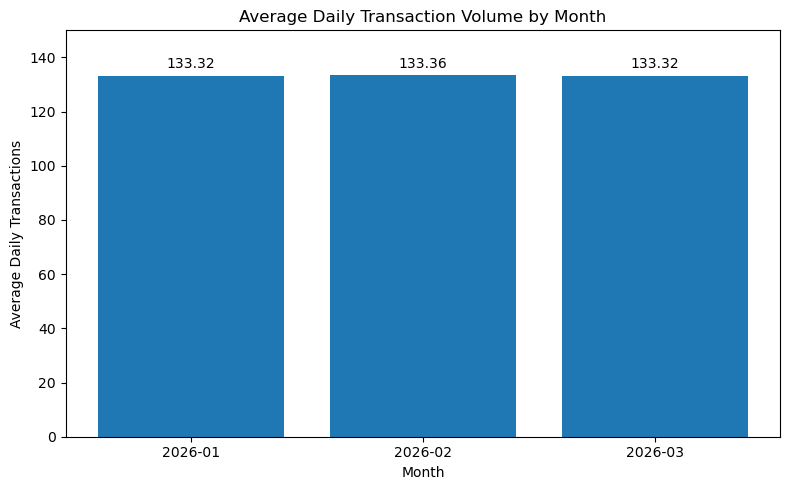

In [31]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    monthly_daily_analysis["Month"],
    monthly_daily_analysis["Average_Daily_Transactions"]
)

plt.title("Average Daily Transaction Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Transactions")

plt.bar_label(
    bars,
    labels=monthly_daily_analysis["Average_Daily_Transactions"],
    padding=3
)

plt.ylim(0, 150)
plt.tight_layout()
plt.show()

#### Interpretation

The monthly totals initially suggested that transaction activity declined in February, with 3,734 transactions compared with 4,133 in both January and March.

However, after normalizing transaction volume by the number of active calendar days, average daily activity was almost identical across the three months: 133.32 transactions per day in January, 133.36 in February, and 133.32 in March.

This indicates that the lower February transaction total was primarily consistent with February having fewer calendar days rather than a meaningful decline in daily transaction activity.

This analysis refines the Week 2 monthly trend finding and demonstrates why monthly totals should be interpreted alongside the length of the reporting period.

### Analysis 3 — High-Value Transaction Patterns

This analysis examines transactions above the overall average transaction value and compares their distribution and risk-review rates across transaction types.

The overall mean is used as an analytical benchmark only and does not represent an official FinTrust high-value transaction threshold.

In [32]:
overall_average = transactions["Amount_NGN"].mean()

high_value = transactions[
    transactions["Amount_NGN"] > overall_average
].copy()

high_value_analysis = (
    high_value.groupby("Transaction_Type")
    .agg(
        High_Value_Transactions=("Transaction_ID", "count"),
        Total_High_Value_NGN=("Amount_NGN", "sum"),
        Average_High_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
)

risk_rates = (
    high_value.assign(
        Risk_Reviewed=high_value["Risk_Review_Flag"].eq("Yes").astype(int)
    )
    .groupby("Transaction_Type")["Risk_Reviewed"]
    .mean()
    .mul(100)
    .reset_index(name="Risk_Review_Rate")
)

high_value_analysis = high_value_analysis.merge(
    risk_rates,
    on="Transaction_Type"
)

high_value_analysis["Total_High_Value_NGN"] = (
    high_value_analysis["Total_High_Value_NGN"].round(2)
)

high_value_analysis["Average_High_Value_NGN"] = (
    high_value_analysis["Average_High_Value_NGN"].round(2)
)

high_value_analysis["Risk_Review_Rate"] = (
    high_value_analysis["Risk_Review_Rate"].round(2)
)

high_value_analysis = high_value_analysis.sort_values(
    "Total_High_Value_NGN",
    ascending=False
)

print("Overall average transaction value: NGN", round(overall_average, 2))
print("Number of high-value transactions:", len(high_value))

high_value_analysis

Overall average transaction value: NGN 46706.45
Number of high-value transactions: 3071


,Transaction_Type,High_Value_Transactions,Total_High_Value_NGN,Average_High_Value_NGN,Risk_Review_Rate
5,Transfer,1207,2.145427e+08,177748.74,32.64
4,Deposit,522,1.216910e+08,233124.49,23.18
2,Card Purchase,643,6.370140e+07,99069.05,15.24
3,Cash Withdrawal,470,5.648015e+07,120170.53,26.81
1,Bill Payment,217,1.490527e+07,68687.86,15.21
0,Airtime/Data,12,5.798604e+05,48321.70,8.33


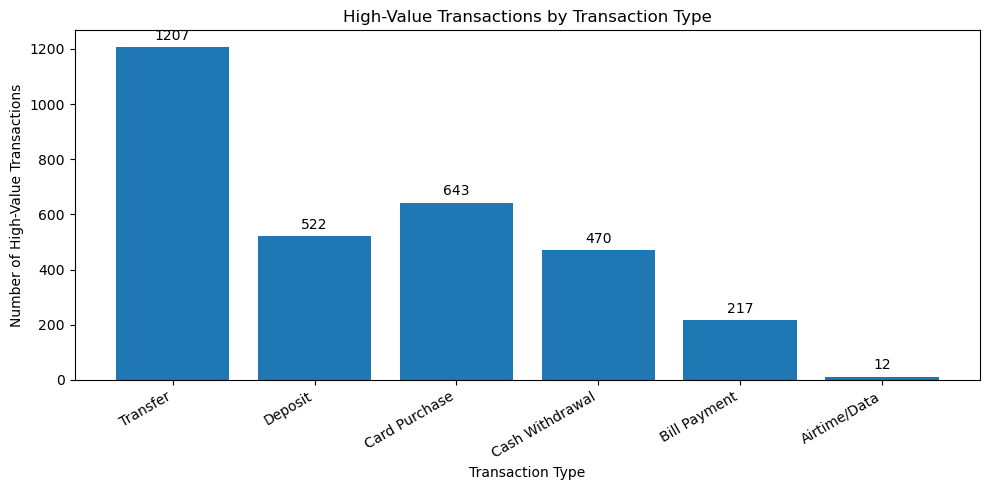

In [33]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    high_value_analysis["Transaction_Type"],
    high_value_analysis["High_Value_Transactions"]
)

plt.title("High-Value Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of High-Value Transactions")

plt.xticks(rotation=30, ha="right")

plt.bar_label(
    bars,
    labels=high_value_analysis["High_Value_Transactions"],
    padding=3
)

plt.tight_layout()
plt.show()

#### Interpretation

Transfers dominated high-value transaction activity, with 1,207 transactions above the overall average transaction value. They also generated approximately NGN 214.54 million in high-value transaction value.

Deposits recorded 522 high-value transactions and had the highest average high-value transaction amount at approximately NGN 233,124.49.

Transfers also recorded the highest risk-review rate among high-value transactions at 32.64%, followed by Cash Withdrawals at 26.81% and Deposits at 23.18%.

The Python results are consistent with the Week 3 SQL high-value transaction analysis, providing cross-tool validation of the finding that Transfers dominate high-value activity while Deposits involve larger average transaction amounts.

The high-value classification used here is an analytical benchmark based on the overall mean transaction amount and does not represent an official FinTrust policy threshold.

### Analysis 4 — Customer Segment Behaviour Comparison

This analysis compares customer segments using transaction frequency per customer and average transaction value. The objective is to determine whether the segment generating more frequent transactions is also the segment generating higher-value transactions.

In [34]:
customer_transactions = transactions.merge(
    customers[["Customer_ID", "Customer_Segment"]],
    on="Customer_ID",
    how="left"
)

segment_analysis = (
    customer_transactions.groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Total_Transactions=("Transaction_ID", "count"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
)

segment_analysis["Transactions_Per_Customer"] = (
    segment_analysis["Total_Transactions"] /
    segment_analysis["Customers"]
)

segment_analysis["Total_Value_NGN"] = (
    segment_analysis["Total_Value_NGN"].round(2)
)

segment_analysis["Average_Value_NGN"] = (
    segment_analysis["Average_Value_NGN"].round(2)
)

segment_analysis["Transactions_Per_Customer"] = (
    segment_analysis["Transactions_Per_Customer"].round(2)
)

segment_analysis = segment_analysis.sort_values(
    "Transactions_Per_Customer",
    ascending=False
)

segment_analysis

,Customer_Segment,Customers,Total_Transactions,Total_Value_NGN,Average_Value_NGN,Transactions_Per_Customer
3,Student,278,2289,1.074759e+08,46953.20,8.23
1,Premium,295,2361,1.077512e+08,45637.95,8.00
0,Everyday,711,5644,2.614589e+08,46325.11,7.94
2,SME,216,1706,8.379137e+07,49115.69,7.90


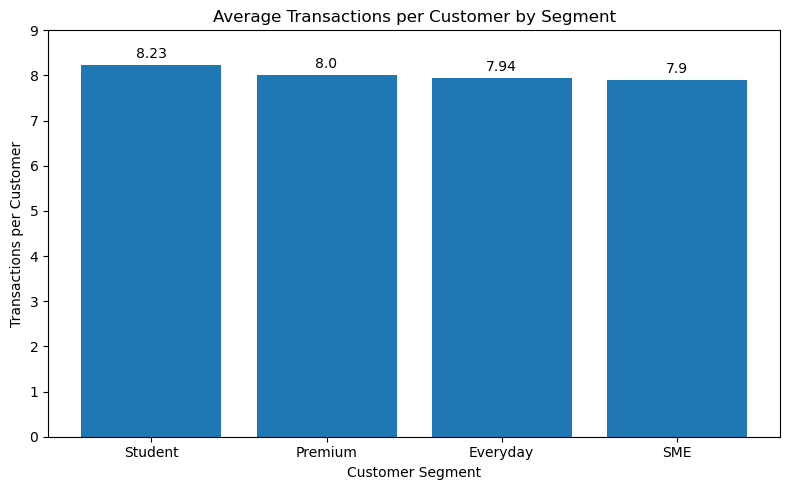

In [35]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    segment_analysis["Customer_Segment"],
    segment_analysis["Transactions_Per_Customer"]
)

plt.title("Average Transactions per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Transactions per Customer")

plt.bar_label(
    bars,
    labels=segment_analysis["Transactions_Per_Customer"],
    padding=3
)

plt.ylim(0, 9)
plt.tight_layout()
plt.show()

#### Interpretation

Student customers recorded the highest transaction frequency at 8.23 transactions per customer, followed by Premium customers at 8.00, Everyday customers at 7.94, and SME customers at 7.90.

However, SME customers recorded the highest average transaction value at approximately NGN 49,115.69, despite having the lowest transaction frequency per customer.

Everyday customers generated the highest overall transaction volume and total transaction value, largely reflecting the larger size of the segment.

The results demonstrate that customer activity should be evaluated using multiple measures. Higher transaction frequency does not necessarily correspond to higher average transaction value or higher total segment value.

The Python results are consistent with the Week 3 SQL customer-segment analysis, providing cross-tool validation of the segment behaviour findings.

### Analysis 5 — International vs Domestic Transaction Analysis

This analysis compares domestic and international transactions based on transaction volume, average transaction value, success rate, and risk-review rate. It also validates the Week 2 finding that international transactions are reviewed at a higher rate than domestic transactions.

In [36]:
international_analysis = (
    transactions.groupby("International_Transaction")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
)

status_analysis = (
    transactions.assign(
        Successful=transactions["Transaction_Status"]
        .eq("Successful")
        .astype(int),

        Risk_Reviewed=transactions["Risk_Review_Flag"]
        .eq("Yes")
        .astype(int)
    )
    .groupby("International_Transaction")
    .agg(
        Success_Rate=("Successful", "mean"),
        Risk_Review_Rate=("Risk_Reviewed", "mean")
    )
    .mul(100)
    .reset_index()
)

international_analysis = international_analysis.merge(
    status_analysis,
    on="International_Transaction"
)

international_analysis["Total_Value_NGN"] = (
    international_analysis["Total_Value_NGN"].round(2)
)

international_analysis["Average_Value_NGN"] = (
    international_analysis["Average_Value_NGN"].round(2)
)

international_analysis["Success_Rate"] = (
    international_analysis["Success_Rate"].round(2)
)

international_analysis["Risk_Review_Rate"] = (
    international_analysis["Risk_Review_Rate"].round(2)
)

international_analysis

,International_Transaction,Total_Transactions,Total_Value_NGN,Average_Value_NGN,Success_Rate,Risk_Review_Rate
0,No,11520,5.404816e+08,46916.80,90.36,18.88
1,Yes,480,1.999578e+07,41657.88,93.12,36.88


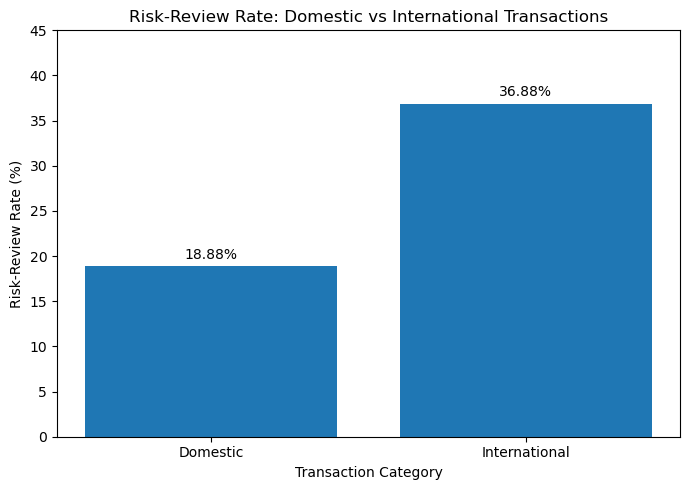

In [37]:
risk_plot = international_analysis.copy()

risk_plot["Transaction_Category"] = risk_plot[
    "International_Transaction"
].map({
    "No": "Domestic",
    "Yes": "International"
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    risk_plot["Transaction_Category"],
    risk_plot["Risk_Review_Rate"]
)

plt.title("Risk-Review Rate: Domestic vs International Transactions")
plt.xlabel("Transaction Category")
plt.ylabel("Risk-Review Rate (%)")

plt.bar_label(
    bars,
    labels=[f"{x:.2f}%" for x in risk_plot["Risk_Review_Rate"]],
    padding=3
)

plt.ylim(0, 45)
plt.tight_layout()
plt.show()

#### Interpretation

International transactions recorded a risk-review rate of 36.88%, compared with 18.88% for domestic transactions. This confirms the Week 2 finding that international transactions are reviewed at a substantially higher rate within the dataset.

However, international transactions recorded a success rate of approximately 93.12%, compared with 90.36% for domestic transactions. International transactions also had a lower average transaction value of approximately NGN 41,657.88, compared with NGN 46,916.80 for domestic transactions.

The results demonstrate that a higher risk-review rate does not correspond to a lower transaction success rate in this dataset. Risk review and transaction success therefore represent different dimensions of transaction activity.

The Python results are consistent with the Week 3 SQL analysis and support the original Week 2 finding regarding international transaction risk-review frequency.

Risk_Review_Flag is a synthetic educational indicator and should not be interpreted as confirmation of fraud or suspicious customer behaviour.